In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neural_network import MLPRegressor
from sklearn.base import BaseEstimator
from typing import Callable
from sklearn.metrics import mean_absolute_error, accuracy_score, mean_absolute_percentage_error, r2_score, root_mean_squared_error
import pandas as pd
import bambi as bmb
import arviz as az
from scipy.stats import norm

# custom 
from utils import ts_parents, all_formulas_from_structures, train_regime_models_bayesian, classify_regime_bayesian, sliding_window_regime_prediction

In [2]:
# data with estimate regime from rpcmci and true regime for test data
data = pd.read_csv("data/simulated_time_series3.csv")

In [3]:
data

,X0,X1,X2,X3,regime
0,0.496714,-0.138264,0.647689,1.523030,0
1,-0.076947,-0.095136,1.987302,1.528950,0
2,-0.528794,1.100696,0.308419,0.298745,0
3,0.360654,-1.380476,-1.760188,-0.412915,0
4,-1.282712,-0.766000,-1.503903,-1.618761,0
...,...,...,...,...,...
695,0.407991,-0.997473,-1.771363,-1.251127,1
696,-0.855416,-0.750910,-1.777783,-2.327977,1
697,-1.331622,-0.118938,-0.341357,-2.021949,1
698,-1.048054,-0.974273,-0.203663,-1.759615,1


In [4]:
#-- causal structures estimated with RPCMCI for each regime
causal_structures = {
    # Regime 0
    0: {
        "X0": [(0, -1),(1,-1)],
        "X1": [(1, -1),(2,-1)],
        "X2": [(2, -1),(0, -1)],
        "X3": [(3, -1)]
        
    },
    # Regime 1
    1: {
        "X0": [(0, -1),(2,-1)],
        "X1": [(1, -1)],
        "X2": [(2, -1),(1, -1)],
        "X3": [(3, -1),(2,-1)]
    }
}

In [5]:
#-- prepare training data
train = data[:500]
#-- filter training data by estimated regime
train1 = train[train['regime'] == 1].drop(columns=['regime'])
train0 = train[train['regime'] == 0].drop(columns=['regime'])
train1_features = ts_parents(train1, causal_structures[1])
train0_features = ts_parents(train0, causal_structures[0])
X_train = {0:train0_features,1:train1_features} # dataset for each regime

In [6]:
all_formulas = all_formulas_from_structures(causal_structures)

In [7]:
all_formulas

{0: {'X0': 'X0 ~ X0_lag1 + X1_lag1',
  'X1': 'X1 ~ X1_lag1 + X2_lag1',
  'X2': 'X2 ~ X2_lag1 + X0_lag1',
  'X3': 'X3 ~ X3_lag1'},
 1: {'X0': 'X0 ~ X0_lag1 + X2_lag1',
  'X1': 'X1 ~ X1_lag1',
  'X2': 'X2 ~ X2_lag1 + X1_lag1',
  'X3': 'X3 ~ X3_lag1 + X2_lag1'}}

In [8]:
bayesian_models = train_regime_models_bayesian(X=X_train, 
                                               all_formulas=all_formulas)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, X0_lag1, X1_lag1]
Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 10 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, X1_lag1, X2_lag1]
Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 9 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, X2_lag1, X0_lag1]
Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 10 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, X3_lag1]
Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 20 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 

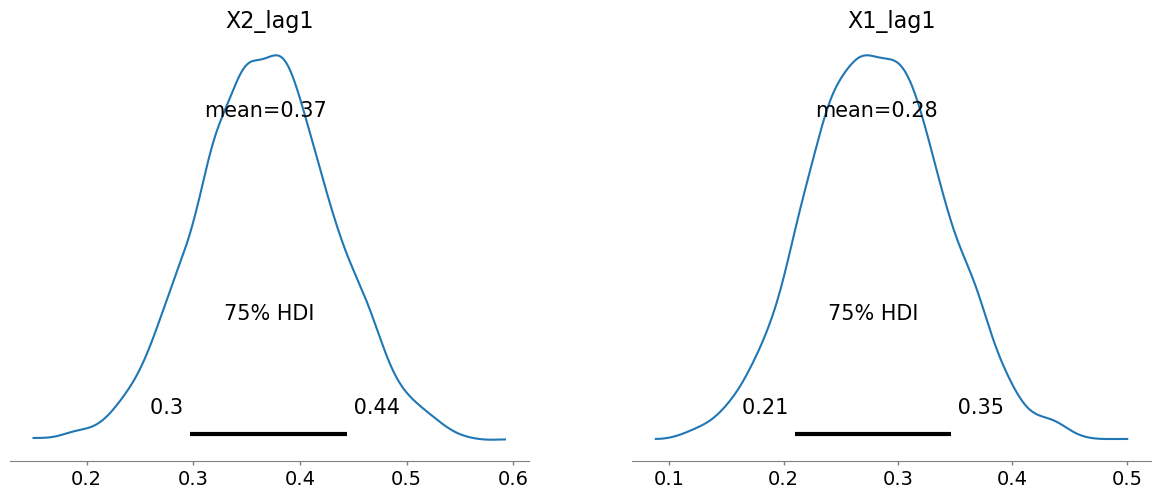

In [9]:
# Regime 1 posterior X2 
# 'X2': 'X2 ~ X2_lag1 + X1_lag1'
# X2_t = 0.4*X2_t-1 + 0.3*X1_t-1
#-- regime_models: regime, variable, [model, idata]
az.plot_posterior(bayesian_models[1]["X2"]["idata"], var_names=['X2_lag1','X1_lag1'], hdi_prob=.75);

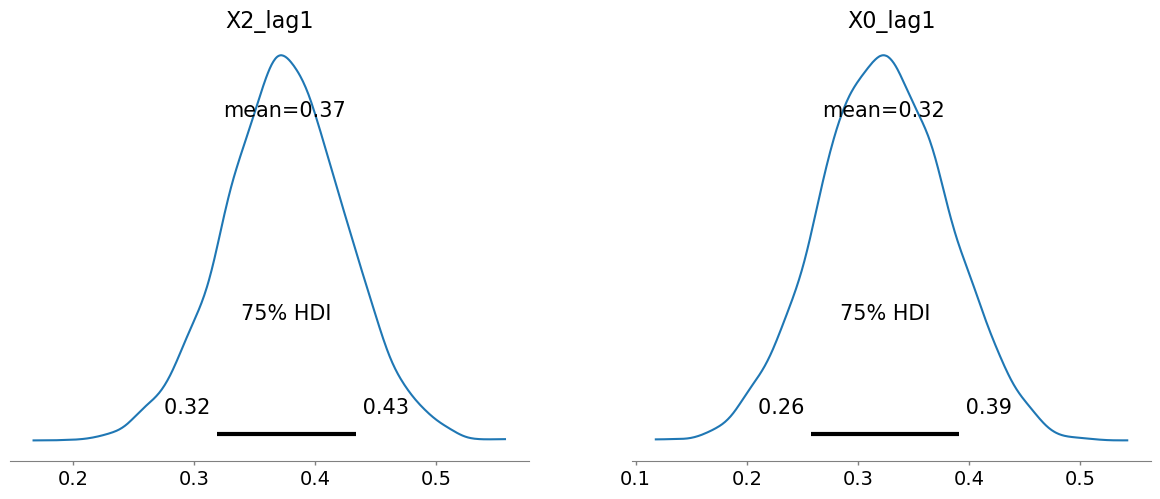

In [10]:
# Regime 0 posterior X2 
# 'X2': 'X2 ~ X2_lag1 + X1_lag1'
# X2_t = 0.4 * data[t - 1, 2] + 0.3 * data[t - 1, 0]
#-- regime_models: regime, variable, [model, idata]
az.plot_posterior(bayesian_models[0]["X2"]["idata"], var_names=['X2_lag1','X0_lag1'], hdi_prob=.75);

In [28]:
w = 35
test = data[500-w:]
actual_regimes = test[['regime']]
test_data = test.drop(columns=['regime'])

test0 = ts_parents(df=test_data, 
                   causal_structure=causal_structures[0]) 
test1 = ts_parents(df=test_data, 
                   causal_structure=causal_structures[1]) 

X_test = {0:test0,1:test1} # test dataset for each regime

In [30]:
regime_prediction, errors = classify_regime_bayesian(
    X_test=X_test, 
    all_formulas=all_formulas, 
    bayesian_models=bayesian_models,
    causal_structures=causal_structures
)

c:\Users\Brandon\miniconda3\envs\bap3_new\lib\site-packages\bambi\models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(
c:\Users\Brandon\miniconda3\envs\bap3_new\lib\site-packages\bambi\models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(
c:\Users\Brandon\miniconda3\envs\bap3_new\lib\site-packages\bambi\models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(
c:\Users\Brandon\miniconda3\envs\bap3_new\lib\site-packages\bambi\models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(
c:\Users\Brandon\miniconda3\envs\bap3_new\lib\site-packages\bambi\models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(
c:\Users\Brandon\miniconda3\envs\bap3_new\lib\site

In [31]:
# classify regime 

true_regime = actual_regimes[w:].values.reshape(-1,)
accuracy_score(regime_prediction[w-1:], true_regime)

0.645

In [32]:
# classify regime with a sliding window of the last w errors 
w = 35
window_preds = sliding_window_regime_prediction(errors, window_size=w)
true_regime = actual_regimes[w:].values.reshape(-1,)
accuracy_score(window_preds, true_regime)

0.905

In [33]:
len(window_preds)

200

In [35]:
window_preds

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [34]:
len(true_regime)

200

# Forecasting

## CaReBayes (Causal Regime Bayesian Forecasting)

In [37]:
data

,X0,X1,X2,X3,regime
0,0.496714,-0.138264,0.647689,1.523030,0
1,-0.076947,-0.095136,1.987302,1.528950,0
2,-0.528794,1.100696,0.308419,0.298745,0
3,0.360654,-1.380476,-1.760188,-0.412915,0
4,-1.282712,-0.766000,-1.503903,-1.618761,0
...,...,...,...,...,...
695,0.407991,-0.997473,-1.771363,-1.251127,1
696,-0.855416,-0.750910,-1.777783,-2.327977,1
697,-1.331622,-0.118938,-0.341357,-2.021949,1
698,-1.048054,-0.974273,-0.203663,-1.759615,1


In [38]:
# Make a deep copy
test_data = data.iloc[498:].copy()

#  Add a 'regime' column cleanly
test_data = test_data.reset_index(drop=True)  
test_data.loc[2:, 'regime'] = window_preds   

In [217]:
test_data

,X0,X1,X2,X3,regime
498,1.282364,1.387091,0.795608,1.655145,0
499,0.902552,-0.088356,0.539885,0.082670,0
500,-0.340664,-0.017895,-0.305700,-0.266627,0
501,-2.035249,0.114425,-0.223274,-0.950402,0
502,-0.120526,0.916358,-2.307444,-1.237926,0
...,...,...,...,...,...
695,0.407991,-0.997473,-1.771363,-1.251127,1
696,-0.855416,-0.750910,-1.777783,-2.327977,1
697,-1.331622,-0.118938,-0.341357,-2.021949,1
698,-1.048054,-0.974273,-0.203663,-1.759615,1


In [39]:
# shift regime one step (the previous classified regime it the causal structure for the forecast)
test_data['regime'] = test_data['regime'].shift(1)
test_data.dropna(inplace=True)

In [41]:
test_data

,X0,X1,X2,X3,regime
1,0.902552,-0.088356,0.539885,0.082670,0.0
2,-0.340664,-0.017895,-0.305700,-0.266627,0.0
3,-2.035249,0.114425,-0.223274,-0.950402,0.0
4,-0.120526,0.916358,-2.307444,-1.237926,0.0
5,-0.542445,-1.265593,-0.129661,-0.812789,0.0
...,...,...,...,...,...
197,0.407991,-0.997473,-1.771363,-1.251127,1.0
198,-0.855416,-0.750910,-1.777783,-2.327977,1.0
199,-1.331622,-0.118938,-0.341357,-2.021949,1.0
200,-1.048054,-0.974273,-0.203663,-1.759615,1.0


In [42]:
test0 = ts_parents(test_data, causal_structures[0])
test1 = ts_parents(test_data, causal_structures[1])


test1_features= test1[test1['regime'] == 1].drop(columns=['regime'])
test0_features = test0[test0['regime'] == 0].drop(columns=['regime'])

In [273]:
# forecasting with bayesian autoregressive model 

# #-- bayesian_models: [regime], [variable], [model, idata]
#-- e.g., bayesian_models[0]["X2"]["idata"]
model = bayesian_models[0]["X2"]["model"]
idata = bayesian_models[0]["X2"]["idata"]


preds0 = model.predict(idata=idata, data=test0_features, kind="pps", inplace=False)
preds0 = preds0.posterior_predictive["X2"]  

mean_pred = preds0.mean(dim=("chain", "draw")).values
lower = preds0.quantile(0.025, dim=("chain", "draw")).values
upper = preds0.quantile(0.975, dim=("chain", "draw")).values

y_test = test0_features["X2"]
y_pred = mean_pred

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.17014906558033605
MAE: 0.8769857228098848
RMSE: 1.061922479088865
MAPE: 8.389698067117612


In [43]:
# forecasting with bayesian autoregressive model 

# #-- bayesian_models: [regime], [variable], [model, idata]
#-- e.g., bayesian_models[0]["X2"]["idata"]
model = bayesian_models[0]["X2"]["model"]
idata = bayesian_models[0]["X2"]["idata"]


preds0 = model.predict(idata=idata, data=test0_features, kind="pps", inplace=False)
preds0 = preds0.posterior_predictive["X2"]  

mean_pred = preds0.mean(dim=("chain", "draw")).values
lower = preds0.quantile(0.025, dim=("chain", "draw")).values
upper = preds0.quantile(0.975, dim=("chain", "draw")).values

y_test = test0_features["X2"]
y_pred = mean_pred

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.1531561292807685
MAE: 0.8602900761504382
RMSE: 1.0424461956738045
MAPE: 7.32232660424697


c:\Users\Brandon\miniconda3\envs\bap3_new\lib\site-packages\bambi\models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


In [44]:
y_preds_total = []
upper_total = []
lower_total = []
y_preds_total.append(y_pred)
upper_total.append(upper) 
lower_total.append(lower)

In [297]:
# forecasting with bayesian autoregressive model 

# #-- bayesian_models: [regime], [variable], [model, idata]
#-- e.g., bayesian_models[0]["X2"]["idata"]
model = bayesian_models[1]["X2"]["model"]
idata = bayesian_models[1]["X2"]["idata"]


preds1 = model.predict(idata=idata, data=test1_features, kind="pps", inplace=False)
preds1 = preds1.posterior_predictive["X2"]  

mean_pred = preds1.mean(dim=("chain", "draw")).values
lower = preds1.quantile(0.025, dim=("chain", "draw")).values
upper = preds1.quantile(0.975, dim=("chain", "draw")).values

y_test = test1_features["X2"]
y_pred = mean_pred

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.27069591182379515
MAE: 0.741725250191774
RMSE: 0.929889924673734
MAPE: 3.2770201589954113


In [45]:
# forecasting with bayesian autoregressive model 

# #-- bayesian_models: [regime], [variable], [model, idata]
#-- e.g., bayesian_models[0]["X2"]["idata"]
model = bayesian_models[1]["X2"]["model"]
idata = bayesian_models[1]["X2"]["idata"]


preds1 = model.predict(idata=idata, data=test1_features, kind="pps", inplace=False)
preds1 = preds1.posterior_predictive["X2"]  

mean_pred = preds1.mean(dim=("chain", "draw")).values
lower = preds1.quantile(0.025, dim=("chain", "draw")).values
upper = preds1.quantile(0.975, dim=("chain", "draw")).values

y_test = test1_features["X2"]
y_pred = mean_pred

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.3170311537769288
MAE: 0.7492493307383202
RMSE: 0.9489567852738463
MAPE: 3.8932865269341383


c:\Users\Brandon\miniconda3\envs\bap3_new\lib\site-packages\bambi\models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


In [46]:
y_preds_total.append(y_pred)
upper_total.append(upper) 
lower_total.append(lower)

In [47]:
bayesian_predictions = np.concatenate((y_preds_total[0], y_preds_total[1]))
bayesian_lower = np.concatenate((lower_total[0], lower_total[1]))
bayesian_upper = np.concatenate((upper_total[0], upper_total[1]))

In [48]:
bayesian_predictions.shape

(200,)

In [61]:
y_test = test["X2"].values

In [62]:
y_test.shape

(235,)

In [55]:
len(bayesian_predictions)

200

In [56]:
y_test.shape

(235,)

In [63]:
y_pred = bayesian_predictions.copy()
y_test = y_test[35:]

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
smape = smape_metric(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"SMAPE: {smape}")

R-squared (R2): 0.23055974625275144
MAE: 0.8164289817126515
RMSE: 1.0065559647156084
MAPE: 5.967855773708402
SMAPE: 134.21657583779285


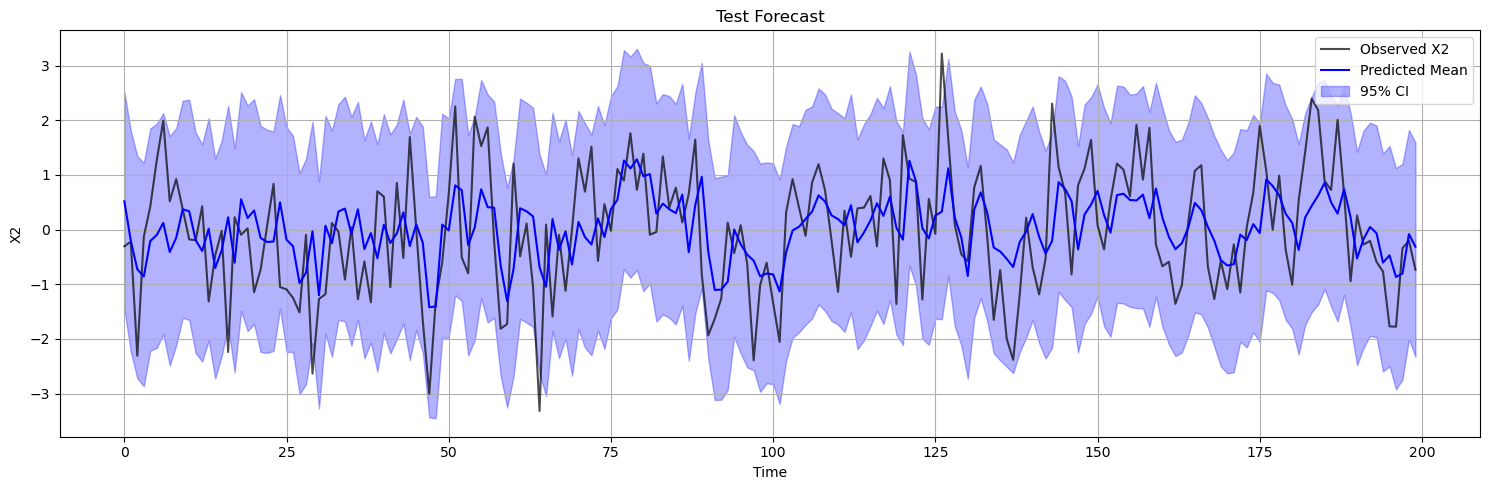

In [304]:
plt.figure(figsize=(15, 5))

# Plot the observed values of X2
plt.plot(range(len(y_test)), y_test, label="Observed X2", color="black", alpha=0.7)

# Plot the predicted posterior mean
plt.plot(range(len(y_test)), bayesian_predictions, label="Predicted Mean", color="blue")

# Plot the uncertainty band (95% credible interval)
plt.fill_between(range(len(y_test)), bayesian_lower, bayesian_upper, color="blue", alpha=0.3, label="95% CI")

# Labels and legend
plt.legend()
plt.xlabel("Time")
plt.ylabel("X2")
plt.title("Test Forecast")
plt.grid(True)
plt.tight_layout()
plt.show()

# Benchmark Models

# Markov-Switching VAR 

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from scipy.stats import norm

In [66]:
df = pd.read_csv('data/simulated_time_series3.csv')


for j in range(4):
    df[f'X{j}_lag1'] = df[f'X{j}'].shift(1)
df = df.dropna().reset_index(drop=True)


train = df.iloc[:499]
test  = df.iloc[499:700]


y_train   = train['X2']                              # target is X2
exog_cols = [f'X{j}_lag1' for j in range(4)]         # lags of X0…X4
exog_train = train[exog_cols]


model = MarkovRegression(
    endog=y_train,
    k_regimes=2,
    exog=exog_train,
    trend='c',
    switching_trend=True,
    switching_exog=True,
    switching_variance=True
)
res = model.fit()

# 6) Extract parameters
p00, p10 = res.params['p[0->0]'], res.params['p[1->0]']
P = np.array([[p00, 1-p00],
              [p10, 1-p10]])
intercepts = np.array([res.params['const[0]'], res.params['const[1]']])
# map exog names: x1→X0_lag1, x2→X1_lag1, …, x5→X4_lag1
betas = np.vstack([
    [res.params[f'x{k+1}[0]'], res.params[f'x{k+1}[1]']]
    for k in range(4)
]).T  # shape (2 regimes × 5 predictors)
sigmas = np.sqrt([res.params['sigma2[0]'], res.params['sigma2[1]']])

one_step_mean = []
one_step_std = []

pi = res.filtered_marginal_probabilities.iloc[-1].values  # last filtered π

for _, row in test.iterrows():
    # propagate regime mix
    pi_pred = pi.dot(P)

    # regime-specific means: intercept + Σ β_j · Xj_lag1
    lag_vals = np.array([row[c] for c in exog_cols])
    mus = intercepts + (betas * lag_vals).sum(axis=1)

    # weighted forecast mean
    y_hat = pi_pred.dot(mus)

    # predictive variance:
    var_hat = pi_pred.dot(sigmas**2 + (mus - y_hat)**2)

    one_step_mean.append(y_hat)
    one_step_std.append(np.sqrt(var_hat))

    # update π with actual observation
    likelihoods = norm.pdf(row['X2'], loc=mus, scale=sigmas)
    pi = pi_pred * likelihoods
    pi /= pi.sum()
one_step_mean = np.array(one_step_mean)
one_step_std = np.array(one_step_std)

In [69]:
y_test = df['X2'][500:]
y_pred = one_step_mean[1:]


# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
smape = smape_metric(y_test.to_numpy(), y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"SMAPE: {smape}")

R-squared (R2): 0.199323665329056
MAE: 0.8316066512560157
RMSE: 1.0292079863339274
MAPE: 5.875510614514138
SMAPE: 136.75754371662532


# VAR

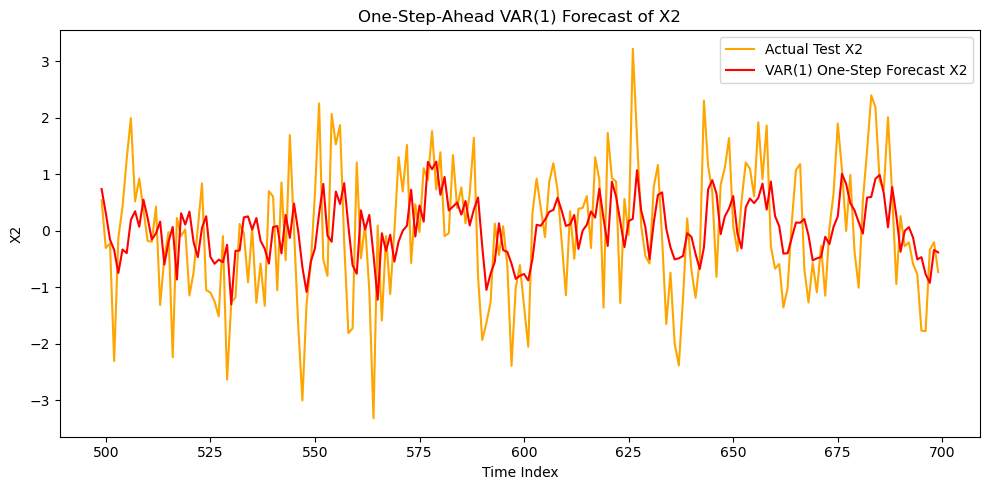

In [71]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Load data
df = pd.read_csv('data/simulated_time_series3.csv')

# Split into training (0-499) and testing (500-699)
train = df.iloc[:499]
test  = df.iloc[499:700]


# Fit VAR(1) on training data
model = VAR(train)
res = model.fit(maxlags=1)

# One-step-ahead forecasts on test range
lag_order = res.k_ar
history = train.values.copy()
one_step_preds = []

for obs in test.values:
    # Forecast one step using last lag_order observations
    last_obs = history[-lag_order:]
    yhat = res.forecast(y=last_obs, steps=1)
    # Extract X2 prediction
    one_step_preds.append(yhat[0, 2])
    # Append the actual observation to history for next forecast
    history = np.vstack([history, obs])

# Convert forecasts to Series aligned with test index
forecast_series = pd.Series(one_step_preds, index=test.index)

# Plot actual vs one-step forecast for X2
plt.figure(figsize=(10, 5))

plt.plot(test.index, test['X2'], label='Actual Test X2', color='orange')
plt.plot(forecast_series.index, forecast_series, label='VAR(1) One-Step Forecast X2', color='red')
plt.xlabel('Time Index')
plt.ylabel('X2')
plt.title('One-Step-Ahead VAR(1) Forecast of X2')
plt.legend()
plt.tight_layout()
plt.show()



In [72]:
y_test = df['X2'][500:]
y_pred = forecast_series[1:]


# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
smape = smape_metric(y_test.to_numpy(), y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"SMAPE: {smape}")

R-squared (R2): 0.19895348298418736
MAE: 0.8312467572939213
RMSE: 1.0270210462946243
MAPE: 6.033597746443364
SMAPE: 136.27805854888578
